<h1 style="font-family: 'Georgia', serif; text-align: center; font-weight: normal; margin-bottom: 0px;">
  <em>Coding Derivates Full Forward and Backward Pass</em>
</h1>
<p style="text-align: center; font-family: 'Georgia', serif; color: gray; margin-top: 5px;">
  Assemble every part together
</p>
<hr style="width: 50%; border: 1px solid #ddd;">

<center>
    <img src="Note-Images/f_b_pass.jpg">
</center>

In [8]:
from nnfs.datasets import spiral_data
import matplotlib.pyplot as plt
import numpy as np

In [10]:
X,y = spiral_data(samples = 200, classes =3)

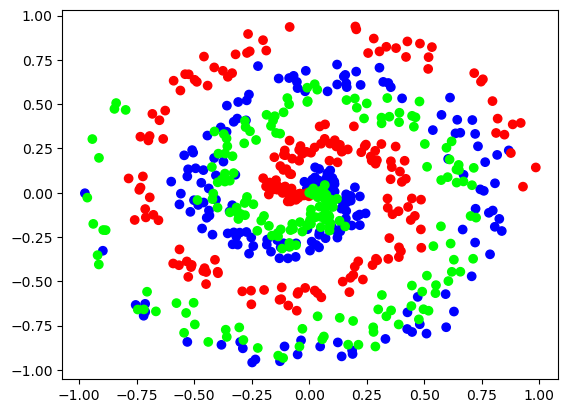

In [12]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'brg')
plt.show()

In [52]:
y_one_hot = np.eye(3)[y]
y_one_hot
X.shape[1]

2

In [82]:
class Dense_Layer:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.1 * np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros((1,n_neurons))
    def forward_pass(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases
        return self.output
    def backward_pass(self, d_values, learning_rate):
        self.dweights = np.dot(self.inputs.T, d_values)
        self.dbiases = np.sum(d_values, axis = 0, keepdims = True)
        self.dinputs = np.dot(d_values, self.weights.T)

        self.weights = self.weights - learning_rate * self.dweights
        self.biases = self.biases - learning_rate * self.dbiases

        return self.dinputs

In [16]:
class ReLU:
    def forward_pass(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(self.inputs, 0)
        return self.output
    def backward_pass(self,dvalues):
        dl_da = np.where(self.inputs > 0 , 1, 0)
        return dl_da * dvalues

In [86]:
class softmax_crossentropy_loss:
    def forward_pass(self, inputs, y_true):
        scaled = np.exp(inputs - np.max(inputs, axis = 1, keepdims = True))
        y_pred_ = scaled / np.sum(scaled, axis = 1, keepdims = True)

        y_pred = np.clip(y_pred_, 1e-7, 1-1e-7)
        final = np.sum(y_pred * y_true, axis =1, keepdims = True)
        loss = -np.log(final)
        return y_pred, loss.mean()   
    def backward_pass(self, y_true, y_pred):
        samples = len(y_pred)
        return (y_pred - y_true) / samples

In [92]:
epochs = 1000
learning_rate = 0.1


In [94]:
layer1 = Dense_Layer(X.shape[1], 5)
activation1 = ReLU()
layer2 = Dense_Layer(5,3)
activation2 = softmax_crossentropy_loss()

for epoch in range(epochs):
    #forward_pass
    output1 = layer1.forward_pass(X)
    relu = activation1.forward_pass(output1)
    output2 = layer2.forward_pass(relu)
    y_pred, loss = activation2.forward_pass(output2, y_one_hot)

    #backward_pass
    d_values1 = activation2.backward_pass(y_one_hot, y_pred)
    d_values2 = layer2.backward_pass(d_values1, learning_rate)
    d_values3 = activation1.backward_pass(d_values2)
    layer1.backward_pass(d_values3, learning_rate)
    if epoch % 49 ==0:
        print(f"epoch:{epoch+1} = Loss:{loss}")   

epoch:1 = Loss:1.0988865189147732
epoch:50 = Loss:1.098560406379035
epoch:99 = Loss:1.0981595088355451
epoch:148 = Loss:1.0975945348507798
epoch:197 = Loss:1.0969967504895233
epoch:246 = Loss:1.0962315649947505
epoch:295 = Loss:1.0952330582740846
epoch:344 = Loss:1.0939254268009022
epoch:393 = Loss:1.092211262447414
epoch:442 = Loss:1.090143403965767
epoch:491 = Loss:1.08781396580595
epoch:540 = Loss:1.085331087150118
epoch:589 = Loss:1.0828606777357894
epoch:638 = Loss:1.0806145449916176
epoch:687 = Loss:1.0787220252178675
epoch:736 = Loss:1.0772268187534106
epoch:785 = Loss:1.076118594671536
epoch:834 = Loss:1.0753227881438256
epoch:883 = Loss:1.0747590076089097
epoch:932 = Loss:1.0743628105147236
epoch:981 = Loss:1.074078541106062
